# Credit Card Campaign Analytics — Python Analysis

### 1. Setup & Imports
### 2. Data Loading & Validation
### 3. Data Cleaning
### 4. Master DataFrame — Merging All Tables
### 5. Campaign Performance Analysis
### 6. ROI vs Conversion Rate — Scatter Analysis
### 7. Customer Segment Analysis
### 8. Time Trend Analysis
### 9. Key Findings Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
conn = sqlite3.connect('../campaign_analytics.db')

customers   = pd.read_sql("SELECT * FROM customers", conn)
campaigns   = pd.read_sql("SELECT * FROM campaigns", conn)
transactions = pd.read_sql("SELECT * FROM transactions", conn)
responses   = pd.read_sql("SELECT * FROM campaign_responses", conn)

conn.close()

In [16]:
customers.head()

,customer_id,age,income,city,segment
0,1,60,"114,105.45",Hyderabad,Affluent
1,2,50,"52,538.42",Kolkata,Mass
2,3,36,"63,592.45",Pune,Mass
3,4,64,"35,798.56",Hyderabad,Mass
4,5,29,"31,602.41",Bangalore,Mass


In [15]:
campaigns.head()

,campaign_id,campaign_type,start_date,end_date,budget
0,C001,Email,2023-01-13,2023-02-14,9012
1,C002,SMS,2023-03-13,2023-04-03,27870
2,C003,Email,2023-10-30,2023-12-11,5520
3,C004,Email,2023-02-17,2023-03-17,8811
4,C005,Email,2023-10-15,2023-11-11,16731


In [14]:
transactions.head()

,transaction_id,customer_id,amount,transaction_date
0,T00001,579,12216,2023-02-11
1,T00002,10,6313,2023-08-31
2,T00003,49,14809,2023-03-01
3,T00004,1511,13588,2023-06-07
4,T00005,623,13713,2023-07-23


In [13]:
responses.head()

,customer_id,campaign_id,response,conversion
0,1110,C009,Clicked,1
1,474,C013,Ignored,0
2,1642,C004,Unsubscribed,0
3,844,C008,Ignored,0
4,1832,C003,Ignored,0


In [5]:
for name, df in [("customers", customers), 
                 ("campaigns", campaigns),
                 ("transactions", transactions), 
                 ("responses", responses)]:
    print(f"\n{'='*40}")
    print(f"{name.upper()}: {df.shape}")
    print(df.dtypes)


CUSTOMERS: (2000, 5)
customer_id      int64
age              int64
income         float64
city            object
segment         object
dtype: object

CAMPAIGNS: (20, 5)
campaign_id      object
campaign_type    object
start_date       object
end_date         object
budget            int64
dtype: object

TRANSACTIONS: (5000, 4)
transaction_id      object
customer_id          int64
amount               int64
transaction_date    object
dtype: object

RESPONSES: (2897, 4)
customer_id     int64
campaign_id    object
response       object
conversion      int64
dtype: object


In [6]:
# convert date columns
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']   = pd.to_datetime(campaigns['end_date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# verification of conversion
print(campaigns[['start_date','end_date']].dtypes)
print(transactions[['transaction_date']].dtypes)

start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object
transaction_date    datetime64[ns]
dtype: object


In [7]:
print("=== Null counts ===")
for name, df in [("customers", customers),
                 ("campaigns", campaigns),
                 ("transactions", transactions),
                 ("responses", responses)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        print(nulls)
    else:
        print(f"\n{name}: no nulls")

=== Null counts ===

customers:
income    87
dtype: int64

campaigns: no nulls

transactions: no nulls

responses: no nulls


In [17]:
print("=== Duplicate checks ===")
print(f"customers:    {customers.duplicated().sum()}")
print(f"campaigns:    {campaigns.duplicated().sum()}")
print(f"transactions: {transactions.duplicated().sum()}")
print(f"responses:    {responses.duplicated(subset=['customer_id','campaign_id']).sum()}")

=== Duplicate checks ===
customers:    0
campaigns:    0
transactions: 0
responses:    0


In [ ]:
# step 1 — link responses to customers
master = responses.merge(
    customers[['customer_id', 'age', 'income', 'city', 'segment']],
    on='customer_id',
    how='left'
)

# step 2 — link to campaigns
master = master.merge(
    campaigns[['campaign_id', 'campaign_type', 'budget']],
    on='campaign_id',
    how='left'
)

# step 3 — link transactions for converted customers only
trans_agg = transactions.groupby('customer_id').agg(
    avg_transaction=('amount', 'mean'),
    transaction_count=('amount', 'count')
).reset_index()

master = master.merge(
    trans_agg,
    on='customer_id',
    how='left'
)

# step 4 — fill nulls for non-converting customers
master['total_spent']        = master['total_spent'].fillna(0)
master['avg_transaction']    = master['avg_transaction'].fillna(0)
master['transaction_count']  = master['transaction_count'].fillna(0)

print(f"Master dataframe shape: {master.shape}")
print(master.dtypes)
print(master.head())

Master dataframe shape: (2897, 13)
customer_id            int64
campaign_id           object
response              object
conversion             int64
age                    int64
income               float64
city                  object
segment               object
campaign_type         object
budget                 int64
total_spent          float64
avg_transaction      float64
transaction_count    float64
dtype: object
   customer_id campaign_id      response  conversion  age    income  \
0         1110        C009       Clicked           1   55 10,554.26   
1          474        C013       Ignored           0   54 61,605.51   
2         1642        C004  Unsubscribed           0   23 35,189.08   
3          844        C008       Ignored           0   38 44,492.68   
4         1832        C003       Ignored           0   55 37,948.03   

        city segment campaign_type  budget  total_spent  avg_transaction  \
0    Kolkata   Youth          Push   20449     7,191.00         1,438.2

In [19]:
master.head()

,customer_id,campaign_id,response,conversion,age,income,city,segment,campaign_type,budget,total_spent,avg_transaction,transaction_count
0,1110,C009,Clicked,1,55,"10,554.26",Kolkata,Youth,Push,20449,"7,191.00","1,438.20",5.00
1,474,C013,Ignored,0,54,"61,605.51",Chennai,Mass,Push,10279,"11,256.00","11,256.00",1.00
2,1642,C004,Unsubscribed,0,23,"35,189.08",Bangalore,Mass,Email,8811,"13,032.00","6,516.00",2.00
3,844,C008,Ignored,0,38,"44,492.68",Hyderabad,Mass,Push,15055,"23,996.00","7,998.67",3.00
4,1832,C003,Ignored,0,55,"37,948.03",Mumbai,Mass,Email,5520,"15,436.00","7,718.00",2.00


In [20]:
master.shape

(2897, 13)

In [22]:
# aggregate campaign metrics
campaign_perf = master.groupby(['campaign_id', 'campaign_type']).agg(
    total_responses=('conversion', 'count'),
    total_conversions=('conversion', 'sum'),
    budget=('budget', 'first'),
).reset_index()

converters = master[master['conversion'] == 1]

campaign_revenue = converters.groupby('campaign_id').agg(
    total_revenue=('total_spent', 'sum')
).reset_index()

campaign_perf = campaign_perf.merge(campaign_revenue, on='campaign_id', how='left')
campaign_perf['total_revenue'] = campaign_perf['total_revenue'].fillna(0)

campaign_perf['conversion_rate'] = (
    campaign_perf['total_conversions'] / 
    campaign_perf['total_responses'] * 100
).round(2)

campaign_perf['roi'] = (
    (campaign_perf['total_revenue'] - campaign_perf['budget']) / 
    campaign_perf['budget'] * 100
).round(2)

campaign_perf = campaign_perf.sort_values('roi', ascending=False)

print(campaign_perf[['campaign_id','campaign_type',
                      'conversion_rate','total_revenue','roi']].to_string())

   campaign_id  campaign_type  conversion_rate  total_revenue       roi
2         C003          Email            12.08   2,890,146.00 52,257.72
0         C001          Email            15.44   4,383,036.00 48,535.55
6         C007          Email            16.90   3,567,505.00 29,818.69
3         C004          Email            14.19   2,515,873.00 28,453.77
17        C018           Push            16.98   2,537,140.00 24,439.51
10        C011           Push            17.59   2,037,106.00 16,749.51
18        C019            SMS            14.69   2,340,808.00 15,145.59
14        C015           Push            11.24   1,523,487.00 13,371.46
7         C008           Push            14.19   1,889,986.00 12,453.88
8         C009           Push            15.71   2,563,761.00 12,437.34
12        C013           Push            14.49   1,137,319.00 10,964.49
9         C010          Email            16.13   1,533,072.00 10,195.29
4         C005          Email            10.77   1,371,549.00  8

#Chart 1 — ROI by Campaign

In [35]:
import os
os.makedirs('./charts', exist_ok=True)

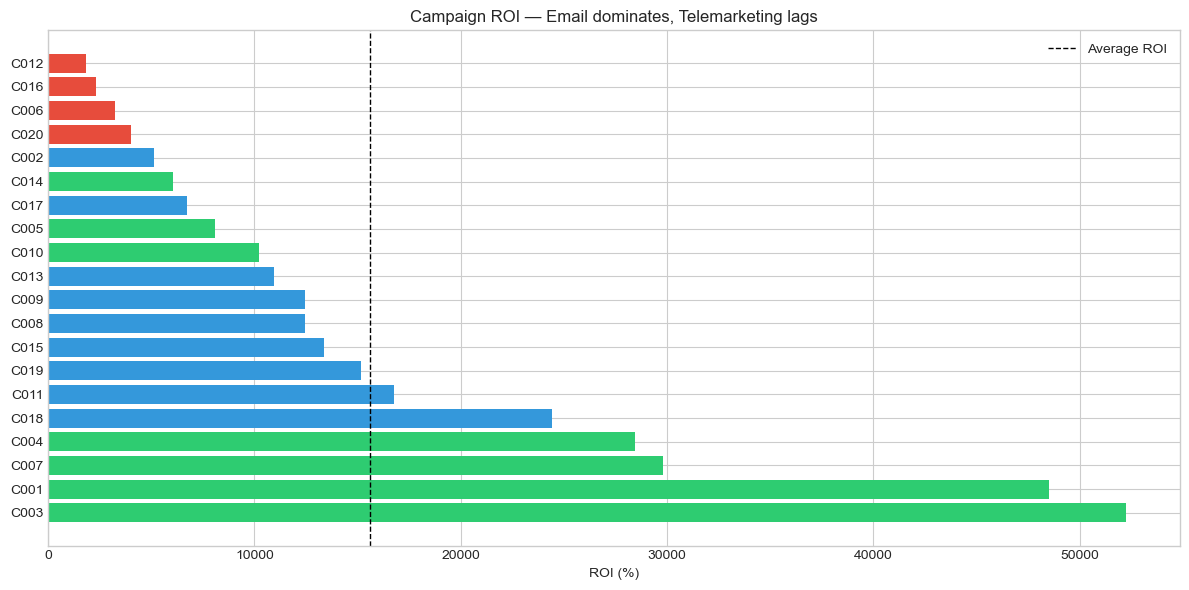

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if ct == 'Email' 
          else '#e74c3c' if ct == 'Telemarketing'
          else '#3498db' for ct in campaign_perf['campaign_type']]

ax.barh(campaign_perf['campaign_id'], 
        campaign_perf['roi'],
        color=colors)

ax.set_xlabel('ROI (%)')
ax.set_title('Campaign ROI — Email dominates, Telemarketing lags')
ax.axvline(x=campaign_perf['roi'].mean(), 
           color='black', linestyle='--', linewidth=1, label='Average ROI')
ax.legend()

plt.tight_layout()
plt.savefig('./charts/01_roi_by_campaign.png', dpi=150)
plt.show()

#Chart 2 — ROI vs Conversion Rate Scatter

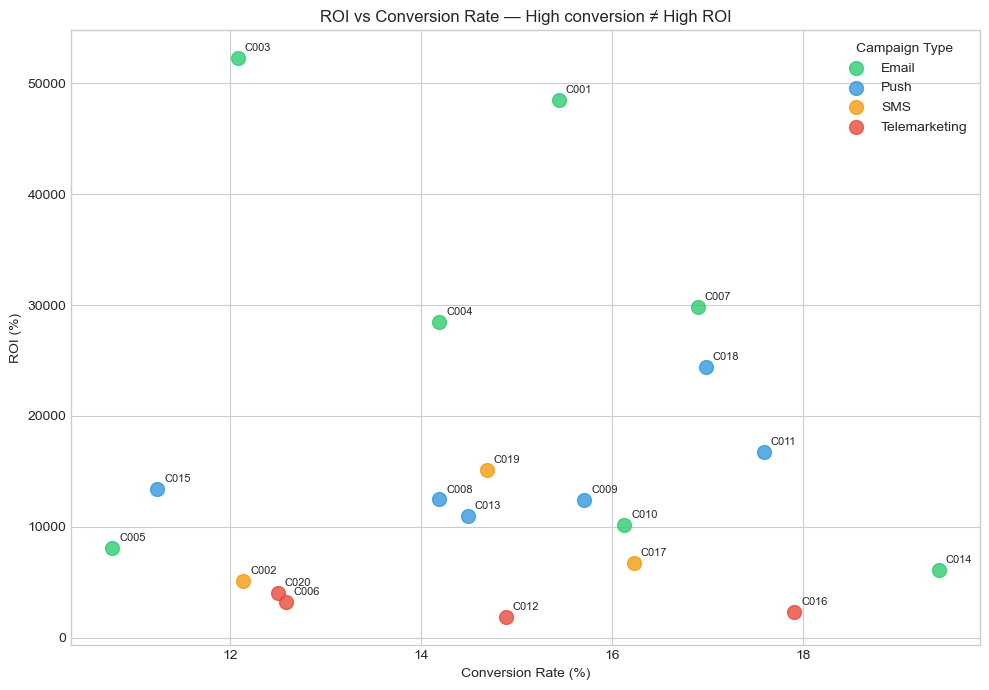

In [38]:
fig, ax = plt.subplots(figsize=(10, 7))

type_colors = {
    'Email': '#2ecc71',
    'Push': '#3498db', 
    'SMS': '#f39c12',
    'Telemarketing': '#e74c3c'
}

for ctype, group in campaign_perf.groupby('campaign_type'):
    ax.scatter(group['conversion_rate'], 
               group['roi'],
               c=type_colors[ctype],
               label=ctype,
               s=100,
               alpha=0.8)
    for _, row in group.iterrows():
        ax.annotate(row['campaign_id'],
                   (row['conversion_rate'], row['roi']),
                   textcoords="offset points",
                   xytext=(5, 5),
                   fontsize=8)

ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('ROI (%)')
ax.set_title('ROI vs Conversion Rate — High conversion ≠ High ROI')
ax.legend(title='Campaign Type')

plt.tight_layout()
plt.savefig('./charts/02_roi_vs_conversion.png', dpi=150)
plt.show()

#Chart 3 — Revenue by Segment

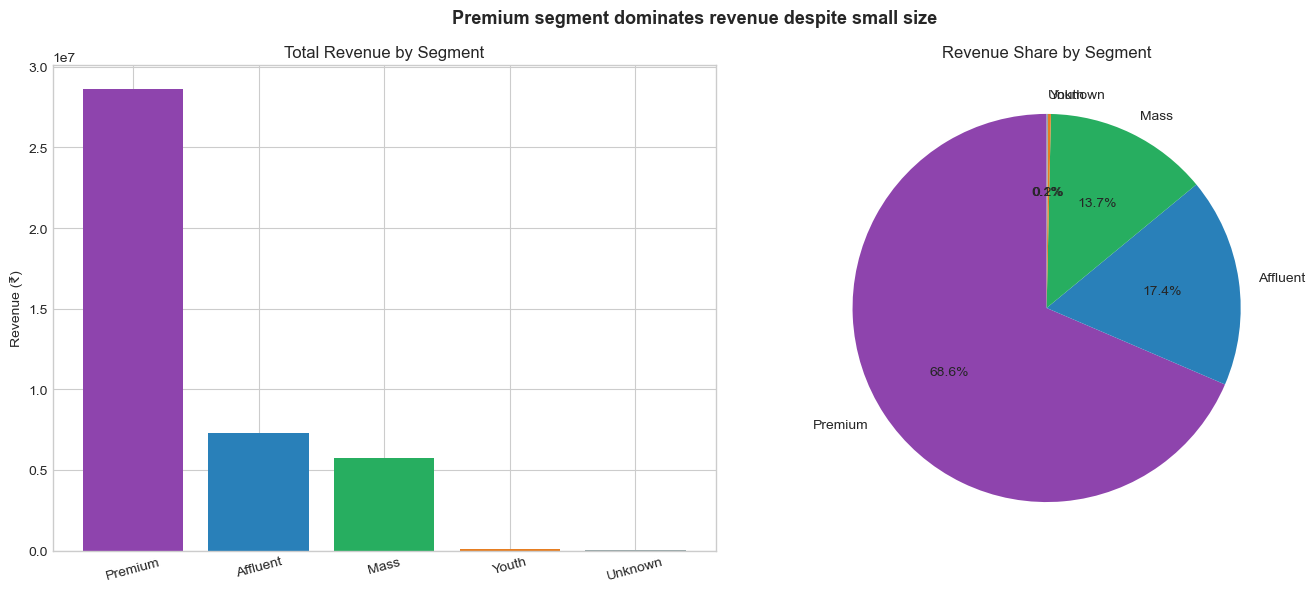

In [40]:
segment_perf = master[master['conversion'] == 1].groupby('segment').agg(
    total_revenue=('total_spent', 'sum'),
    unique_customers=('customer_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left — revenue bar
axes[0].bar(segment_perf['segment'], 
            segment_perf['total_revenue'],
            color=['#8e44ad','#2980b9','#27ae60','#e67e22','#95a5a6'])
axes[0].set_title('Total Revenue by Segment')
axes[0].set_ylabel('Revenue (₹)')
axes[0].tick_params(axis='x', rotation=15)

# right — revenue share donut
axes[1].pie(segment_perf['total_revenue'],
            labels=segment_perf['segment'],
            autopct='%1.1f%%',
            startangle=90,
            colors=['#8e44ad','#2980b9','#27ae60','#e67e22','#95a5a6'])
axes[1].set_title('Revenue Share by Segment')

plt.suptitle('Premium segment dominates revenue despite small size', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./charts/03_revenue_by_segment.png', dpi=150)
plt.show()

#Chart 4 — Monthly Revenue Trend

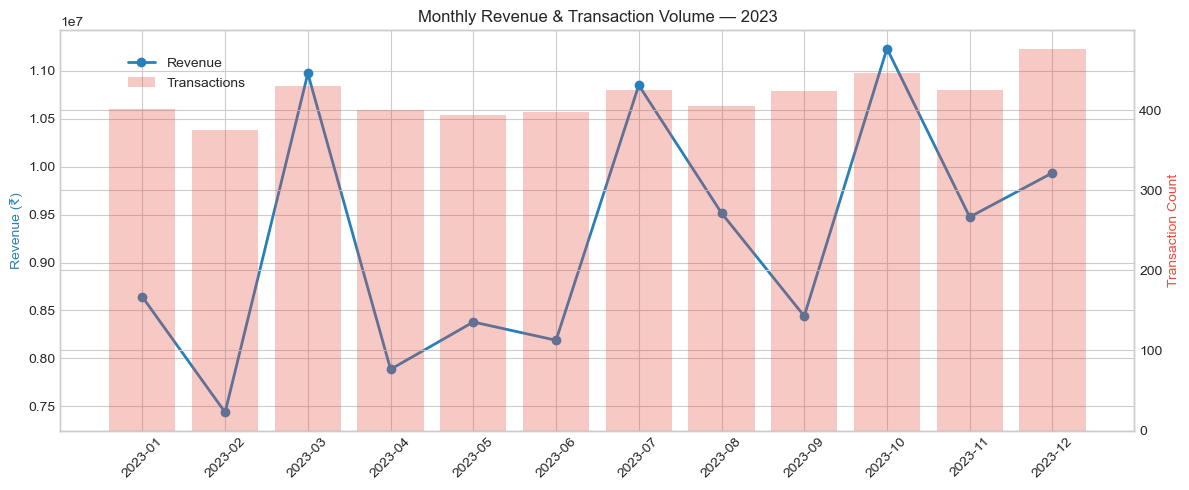

In [42]:
monthly = transactions.copy()
monthly['month'] = pd.to_datetime(monthly['transaction_date']).dt.to_period('M')
monthly_agg = monthly.groupby('month').agg(
    revenue=('amount', 'sum'),
    transactions=('amount', 'count')
).reset_index()
monthly_agg['month'] = monthly_agg['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_agg['month'], 
         monthly_agg['revenue'],
         color='#2980b9', linewidth=2, marker='o', label='Revenue')
ax1.set_ylabel('Revenue (₹)', color='#2980b9')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.bar(monthly_agg['month'], 
        monthly_agg['transactions'],
        alpha=0.3, color='#e74c3c', label='Transactions')
ax2.set_ylabel('Transaction Count', color='#e74c3c')

ax1.set_title('Monthly Revenue & Transaction Volume — 2023')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.tight_layout()
plt.savefig('./charts/04_monthly_trend.png', dpi=150)
plt.show()

## Key Findings

1. **Conversion rate is a misleading metric** — C014 had the highest 
   conversion rate (19.42%) but the lowest ROI, proving that engagement 
   alone does not guarantee returns

2. **Email campaigns deliver the best ROI** — lowest budgets but highest 
   returns, making Email the most cost-efficient channel

3. **Telemarketing consistently underperformed** — highest budgets across 
   all campaigns but bottom 4 ROI positions, high operational cost 
   erodes returns regardless of conversion rate

4. **Premium segment drives disproportionate revenue** — only 5.6% of 
   customers but 75% of total revenue, Premium customers spend 
   significantly more per transaction than Mass segment

5. **Revenue peaked in March, July and October** — February was the 
   weakest month and is the strongest candidate for targeted 
   campaign push

6. **ROI figures reflect synthetic data scale** — absolute percentages 
   are inflated due to conservative budget ranges relative to 
   transaction amounts, relative rankings across campaigns remain valid

In [43]:
print("=== PROJECT SUMMARY ===")
print(f"Total Campaigns Analyzed: {len(campaigns)}")
print(f"Total Customers: {len(customers)}")
print(f"Total Responses: {len(responses)}")
print(f"Overall Conversion Rate: {responses['conversion'].mean():.1%}")
print(f"Best ROI Campaign: {campaign_perf.iloc[0]['campaign_id']} "
      f"({campaign_perf.iloc[0]['campaign_type']}) "
      f"— ROI {campaign_perf.iloc[0]['roi']:,.0f}%")
print(f"Worst ROI Campaign: {campaign_perf.iloc[-1]['campaign_id']} "
      f"({campaign_perf.iloc[-1]['campaign_type']}) "
      f"— ROI {campaign_perf.iloc[-1]['roi']:,.0f}%")
print(f"Top Revenue Segment: Premium")
print(f"Premium Revenue Share: 75%")

=== PROJECT SUMMARY ===
Total Campaigns Analyzed: 20
Total Customers: 2000
Total Responses: 2897
Overall Conversion Rate: 14.7%
Best ROI Campaign: C003 (Email) — ROI 52,258%
Worst ROI Campaign: C012 (Telemarketing) — ROI 1,829%
Top Revenue Segment: Premium
Premium Revenue Share: 75%
